In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

In [2]:

def planck_function_wavenumber(nu, T):
    # Constants
    h = 6.62607015e-34     # Planck's constant in J·s
    c = 2.99792458e10      # Speed of light in cm/s
    k_B = 1.380649e-23     # Boltzmann constant in J/K

    # Planck function
    B_nu = (2 * h * c**2 * nu**3) / (np.exp((h * c * nu) / (k_B * T)) - 1)
    
    return B_nu
    

In [3]:
all_met = xr.open_dataset("/global/homes/r/rudisill/gshare/sail_data_will/data_store_sail_period/gucmet/all_met.nc")

In [4]:
mwr = xr.open_dataset("/global/homes/r/rudisill/gshare/sail_data_will/data_store_sail_period/gucmwrlos/vap_and_liquid_mwrlos3.nc")


In [5]:
lwp10m = mwr.vap.where(mwr.qc_vap ==0)

In [6]:
# fig, ax = plt.subplots()
# ax.plot(1E7 / dsr.isel(time=35).wnum / 1E3 , dsr.isel(time=20))
# ax.plot(1E7 / dsr2.isel(time=30).wnum / 1E3 , dsr2.isel(time=30))


# ax.set_xlabel('Wavelength (um)')
# ax.axvline(15, linestyle='--')

In [7]:
kolias = xr.open_dataset("/global/homes/r/rudisill/gshare/sail_data_will/data_store_sail_period/kollias/cbh_kolias2.nc").to_pandas()
cloud_present_kolias = kolias.copy()
cloud_present_kolias[cloud_present_kolias == -1] = 0
cloud_present_kolias[cloud_present_kolias > 0] = 1


kolias_lt_4000 = kolias.where(kolias < 6000)
kolias_lt_4000.fillna(-1, inplace=True)
cloud_present_kolias_lt_6000 = kolias_lt_4000.copy()
cloud_present_kolias_lt_6000[cloud_present_kolias_lt_6000 == -1] = 0
cloud_present_kolias_lt_6000[cloud_present_kolias_lt_6000 > 0] = 1



In [8]:
cfrac = cloud_present_kolias_lt_6000.resample("10min").mean()


In [9]:
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable


In [10]:
from matplotlib.gridspec import GridSpec


In [11]:
def get_data_by_day(year, month, day):
    # year  = '2022'
    # month = '08'
    # day   = '02'

    date  = "%s %s %s" % (year, month, day)
    tr= slice(date + ' 01', date + ' 23')

    # find the aerir file
    aerif = glob.glob("/global/cfs/cdirs/m4099/gsharing/sail_data_will/data_store_sail_period/aeri/ftp.archive.arm.gov/rudisillw2/241791/gucaerich1M1.b1." + year+month+day + "*")
    aeri = xr.open_dataset(aerif[0])
    all_mean_rad10min = aeri.mean_rad.load()


    # find the kazr file...
    kazrf     = glob.glob("/global/cfs/cdirs/m4099/gsharing/sail_data_will/data_store_sail_period/kazr/dates_fixed/*" + year+month+day + "*")
    kzar_01   = xr.open_mfdataset(kazrf)
    kzar_r10  = kzar_01.reflectivity.resample(time='10min').mean().load()


    return kzar_r10, all_mean_rad10min, tr 



def plot_day(kzar_r10, all_mean_rad10min, tr):
    # now make the plot 
    # fig, ax = plt.subplots(4, 1, sharex=False, figsize=(6, 9))

    fig = plt.figure(figsize=(8, 6))
    gs = GridSpec(4, 2, figure=fig, width_ratios=[1, 0.025])  # Last column for colorbar

    # Define subplots in the grid
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])
    ax4 = fig.add_subplot(gs[3, 0])

    cax1 = fig.add_subplot(gs[0, 1])
    cax3 = fig.add_subplot(gs[2, 1])


    ax   = [ax1, ax2, ax3, ax4]
#    cax  = [cax1, cax2, cax3, cax4]

    cb=kzar_r10.sel(time=tr).plot(x='time', y='range', ax=ax[0], add_colorbar=True, cbar_ax=cax1, cbar_kwargs={'label': 'Reflectivity (dBZ)'})


    ax[0].set_ylim(0,8000)


    ax[1].plot(cfrac.loc[tr].index, cfrac.loc[tr].values, color='black')

    ### plot the aerir 

    amr10 = all_mean_rad10min.sel(time=tr).resample(time="10min").mean()

    #plot(vmin=0, vmax=100, x='time', ax=ax[2], add_colorbar=False)
    #ax.pcolormesh(1E7 / amr10.wnum / 1E3 , dsr.isel(time=20))
    #ax[2].pcolormesh(amr10.time, 1E7/amr10.wnum / 1E3, amr10.values.T)
    im=ax[2].pcolormesh(amr10.time, amr10.wnum, amr10.values.T)
    cb=fig.colorbar(im, cax=cax3)
    cb.set_label('Radiance (W/m^2/sr/cm^-1)')

#    ax[2].set_yticks(np.arange(6,20,2))

    ax[2].set_yticks(np.arange(600,2000,200))
    ax32 = ax[3].twinx()
    lwp10m.sel(time=tr).plot(x='time', ax=ax[3])
    all_met['temp_mean'].sel(time=tr).plot(x='time', ax=ax32, color='red')


    for i in [0,1,2]:
        ax[i].set_xticks([])
        ax[i].set_xlabel('')


    ax[0].set_ylabel("height agl (m)")
    ax[1].set_ylabel("cloudfrac arscl")
    ax[2].set_ylabel('Wavenumber\n cm $^{-1}$')
#    ax[2].set_ylabel('wavelength (um)')

#    ax[3].set_ylabel("VPkPa")
    ax[3].set_ylabel("PWV (cm)")
    ax32.set_ylabel("Temp C", color='red')

    # xlabel
    ax[3].set_xlabel("Time (UTC)")
    return fig, ax
    plt.tight_layout()  





In [40]:

def plot_wnrad(amr10, dt1, dt2, ax=False):
    if not ax:
        fig, ax = plt.subplots()
    
    # s1 = amr10.sel(time=pd.to_datetime('2022-08-02 18:00:00'))
    # s2 = amr10.sel(time=pd.to_datetime('2022-08-02 08:00:00'))
    # surfacet1 = all_met['temp_mean'].sel(time=pd.to_datetime('2022-08-02 18:00:00'))
    # surfacet2 = all_met['temp_mean'].sel(time=pd.to_datetime('2022-08-02 08:00:00'))
    s1 = amr10.sel(time=pd.to_datetime(dt1), method='nearest')
    s2 = amr10.sel(time=pd.to_datetime(dt2), method='nearest')

    surfacet1 = all_met['temp_mean'].sel(time=pd.to_datetime(dt1) , method='nearest')
    surfacet2 = all_met['temp_mean'].sel(time=pd.to_datetime(dt2) , method='nearest')
    #ax.plot(1E7/s1.wnum / 1E3, s1.values)
    #ax.plot(1E7/s2.wnum / 1E3, s2.values)
    #plt.plot(1E7/s1.wnum / 1E3, s1.values)
    #plt.plot(1E7/s2.wnum / 1E3, s2.values)
    #(planck_function_wavenumber(s1.wnum , 300.00) * 1E7).plot(label='300K', color='gray', linestyle='--', alpha=0.5)
    #(planck_function_wavenumber(s1.wnum , 270.00) * 1E7).plot(label='270K', color='gray', linestyle='--', alpha=0.5)
    #(planck_function_wavenumber(s1.wnum , 240.00) * 1E7).plot(label='240K', color='gray', linestyle='--', alpha=0.5)
    (planck_function_wavenumber(s1.wnum , surfacet1+273.15) * 1E7).plot(color='gray', linestyle='--', alpha=0.5, ax=ax, linewidth=.5)
    (planck_function_wavenumber(s2.wnum , surfacet2+273.15) * 1E7).plot(color='gray', linestyle='--', alpha=0.5, ax=ax, linewidth=.5)

    s1.plot(label='cloud', ax=ax, linewidth=.5)
    s2.plot(label='no cloud', ax=ax, linewidth=.5)

    ax.legend()


In [13]:
kzar_r10_summer, all_mean_rad10min_summer, tr_summer  = get_data_by_day('2022', '08', '29')


Text(2022-08-29 08:15:00, 5500, 't2')

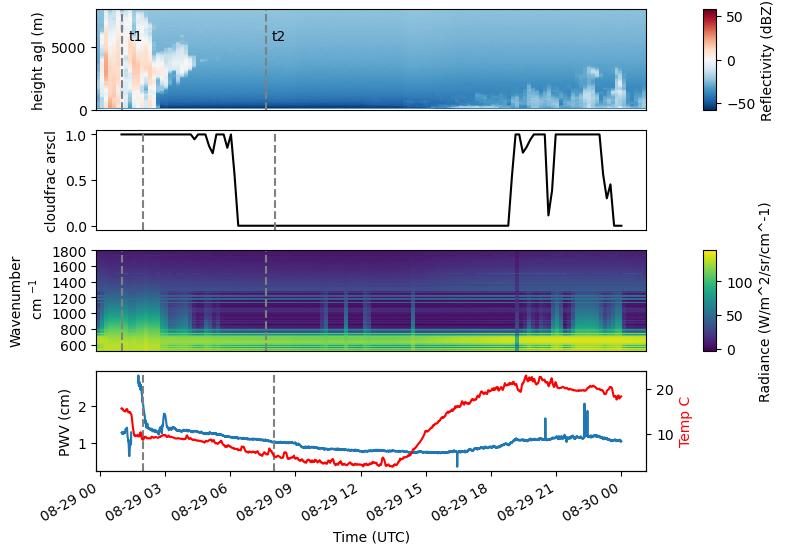

In [14]:
fig, ax = plot_day(kzar_r10_summer, all_mean_rad10min_summer, tr_summer)


# '2022-08-29 02', '2022-08-29 08'


for axx in ax:
    axx.axvline(pd.to_datetime('2022-08-29 02'), linestyle='--', color='gray')
    axx.axvline(pd.to_datetime('2022-08-29 08'), linestyle='--', color='gray')

ax[0].text(pd.to_datetime('2022-08-29 02:15'), 5500, "t1")
ax[0].text(pd.to_datetime('2022-08-29 08:15'), 5500, "t2")

In [16]:
#1/ax.get_xticks() * 1E7 / 1E3

In [ ]:
ax

[<AxesSubplot: ylabel='height agl (m)'>,
 <AxesSubplot: ylabel='cloudfrac arscl'>,
 <AxesSubplot: ylabel='Wavenumber\n cm $^{-1}$'>,
 <AxesSubplot: xlabel='Time (UTC)', ylabel='PWV (cm)'>]

In [17]:
kzar_r10_winter, all_mean_rad10min_winter, tr_winter  = get_data_by_day('2021', '12', '16')

Text(2021-12-16 10:15:00, 5500, 't2')

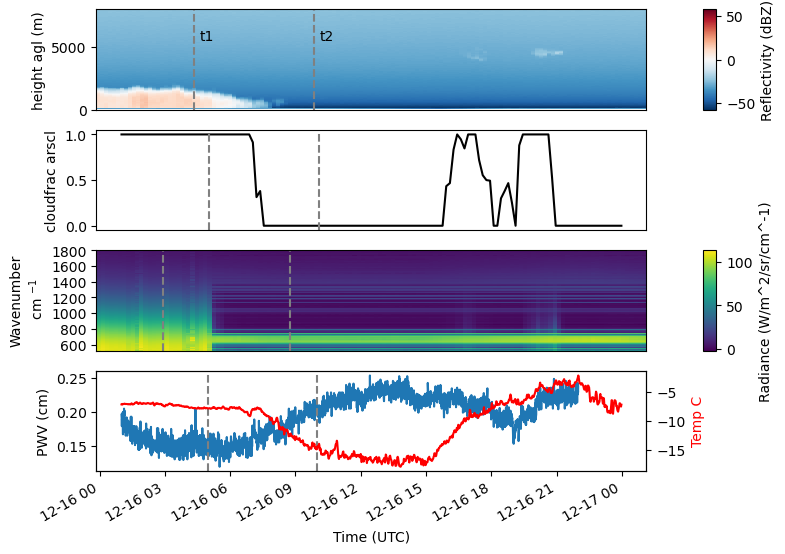

In [18]:
fig, ax = plot_day(kzar_r10_winter, all_mean_rad10min_winter, tr_winter) 
for axx in ax:
    axx.axvline(pd.to_datetime('2021-12-16 05'), linestyle='--', color='gray')
    axx.axvline(pd.to_datetime('2021-12-16 10'), linestyle='--', color='gray')


ax[0].text(pd.to_datetime('2021-12-16 05:15'), 5500, "t1")
ax[0].text(pd.to_datetime('2021-12-16 10:15'), 5500, "t2")

Text(0.5, 1.0, '')

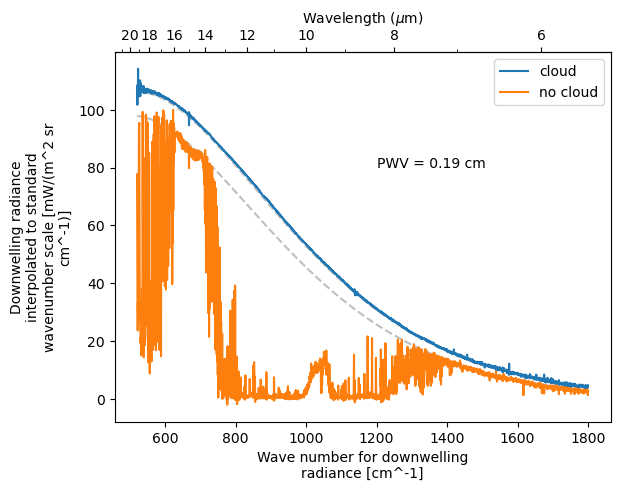

In [23]:
from matplotlib.ticker import MultipleLocator


fig, ax = plt.subplots()

plot_wnrad(all_mean_rad10min_winter, '2021-12-16 05', '2021-12-16 10', ax=ax)

pwv=lwp10m.sel(time=tr_winter).mean().values 

ax.text(1200, 80, "PWV = %.2f cm" % pwv)


# def convert_to_new_units(x):
#     return x * 2  # Example conversion (e.g., doubling the units)

um = np.arange(6, 32, 2)
secax = ax.secondary_xaxis('top')
secax.set_xticks(1/(um * 1E-4))
secax.set_xticklabels(um)
secax.set_xlabel('Wavelength ($\mu$m)')

# minor_locator = MultipleLocator(1)  # Minor ticks every 5 in the converted units
# secax.xaxis.set_minor_locator(minor_locator)

um_minor = np.arange(4, 32, 1)
secax.set_xticks(1/(um_minor * 1E-4), minor=True)




ax.set_title("")

# ax1.set_xticks(1/(um * 1E-4))
# ax1.set_xticklabels(um)

Text(1200, 80, 'PWV = 1.05 cm')

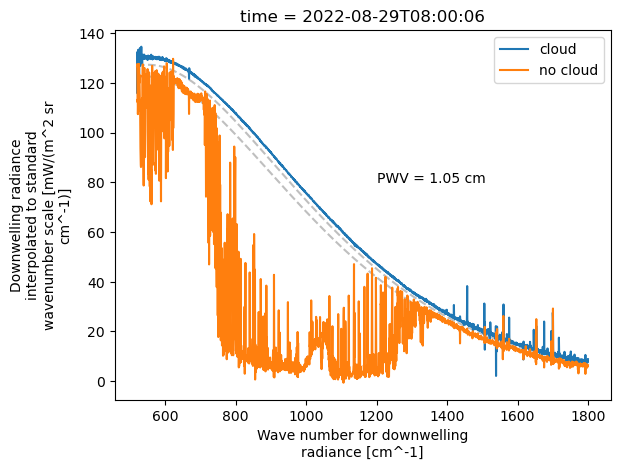

In [ ]:
fig, ax = plt.subplots()
plot_wnrad(all_mean_rad10min_summer,  '2022-08-29 02', '2022-08-29 08', ax=ax)
pwv=lwp10m.sel(time=tr_summer).mean().values 
ax.text(1200, 80, "PWV = %.2f cm" % pwv)

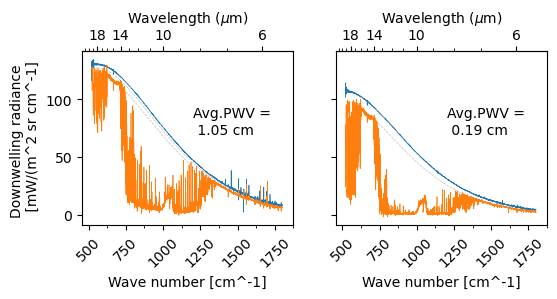

In [42]:
fig, ax = plt.subplots(1,2, figsize=(6, 2.25,), sharey=True)
plot_wnrad(all_mean_rad10min_summer,  '2022-08-29 02', '2022-08-29 08', ax=ax[0])
pwv=lwp10m.sel(time=tr_summer).mean().values 
ax[0].text(1200, 70, "Avg.PWV =\n %.2f cm" % pwv)
ax[0].set_title("a) warm season scene")

# do the 2nd one 

plot_wnrad(all_mean_rad10min_winter, '2021-12-16 05', '2021-12-16 10', ax=ax[1])

pwv=lwp10m.sel(time=tr_winter).mean().values 

ax[1].text(1200, 70, "Avg.PWV =\n %.2f cm" % pwv)
ax[1].set_ylabel('')
ax[1].set_title("b) cold season scene")

ax[0].set_ylabel("Downwelling radiance \n [mW/(m^2 sr cm^-1]")

ax[0].set_xlabel("Wave number [cm^-1]")
ax[1].set_xlabel("Wave number [cm^-1]")


ax[0].legend_.remove()
ax[1].legend_.remove()

## add axes 
um = np.arange(6, 32, 4)
um_minor = np.arange(4, 32, 1)

for axx in ax:
    # set the top axes
    secax = axx.secondary_xaxis('top')
    secax.set_xticks(1/(um * 1E-4))
    secax.set_xticklabels(um)
    secax.set_xlabel('Wavelength ($\mu$m)')
    secax.set_xticks(1/(um_minor * 1E-4), minor=True)
    axx.set_title("")

    # add some minor ticklabels to the bottom 
    axx.set_xticks(np.arange(500, 2000, 250), minor=False)
    axx.set_xticks(np.arange(500, 2000, 250/2), minor=True)
    axx.set_xticklabels(axx.get_xticklabels(), rotation=45)

#plt.tight_layout()
plt.savefig("FigureX_aeri_rad", dpi=300, bbox_inches='tight')

In [ ]:
pwd

'/global/u1/r/rudisill'

/tmp/ipykernel_1648129/584094988.py:8: RuntimeWarning: invalid value encountered in divide
  B_nu = (2 * h * c**2 * nu**3) / (np.exp((h * c * nu) / (k_B * T)) - 1)


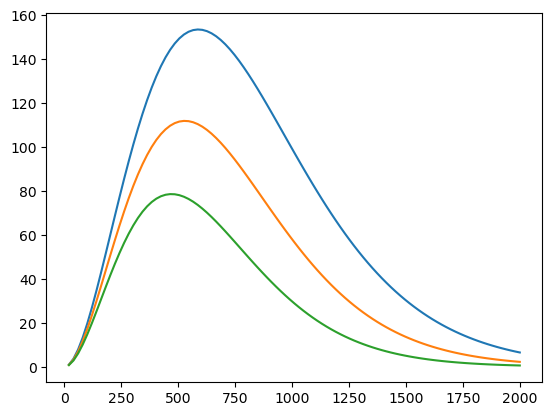

In [ ]:
wn = np.linspace(0, 2000,100)

plt.plot(wn, planck_function_wavenumber(wn, 300) * 1E7)
plt.plot(wn, planck_function_wavenumber(wn, 270) * 1E7)
plt.plot(wn, planck_function_wavenumber(wn, 240) * 1E7)

